# Basic Data Visualisation using Matplotlib

### Preproccesing data using Pandas

In [ ]:
import pandas as pd
%pip install openpyxl==3.1.0

In [ ]:
df_can = pd.read_excel(
    'https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-DV0101EN-SkillsNetwork/Data%20Files/Canada.xlsx',
    sheet_name='Canada by Citizenship', # Assigned the ss page
    skiprows=range(20), # Skips first 20 lines in the ss
    skipfooter=2) # Skips the bottom two lines in the ss

In [ ]:
# Removes some unnecessary variables

df_can = df_can.drop(['AREA','REG','DEV','Type','Coverage'], axis=1)

In [ ]:
# Rename some columns

df_can = df_can.rename(columns={'OdName':'Country', 'AreaName':'Continent', 'RegName':'Region'})

In [ ]:
# Add a total immigrants column

df_can['Total'] = df_can.select_dtypes(include='int64').sum(axis = 1)

In [ ]:
# Setting df index for easier browsing
df_can = df_can.set_index('Country')

In [ ]:
# Check Haiti between values

df_can.loc['Haiti', [1990, 1991, 1992, 1993, 1994, 1995]]

In [ ]:
# Setting column names to string

df_can.columns = list(map(str, df_can.columns))

In [ ]:
# Making a list of years for plotting later

years = list(map(str, range(1980, 2014)))

In [ ]:
# Filtering df using a criteria

condition = df_can["Continent"] == "Asia"
df_can_asia = df_can[condition]

In [ ]:
# We can filter in one line and use multiple criterias

df_can_asia_s = df_can[(df_can['Continent']=='Asia') & (df_can['Region']=='Southern Asia')]

In [ ]:
# Sorting values

df_can.sort_values(by='Total', ascending=False, axis=0, inplace=True)

### Introduction to Matplotlib and Line plots

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
# Creating a dataseries using previous Years list

haiti = df_can.loc["Haiti", years]

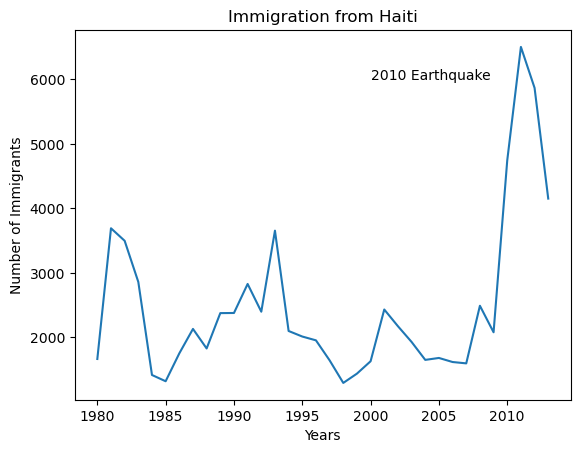

In [25]:
# Line graph

haiti.index = haiti.index.map(int) 
haiti.plot(kind='line')

plt.title('Immigration from Haiti')
plt.ylabel('Number of Immigrants')
plt.xlabel('Years')

# annotate the 2010 Earthquake. 
# syntax: plt.text(x, y, label)
plt.text(2000, 6000, '2010 Earthquake') # see note below

plt.show() 